# Market Stats — Distribution Analysis, All 20 Political Markets

Statistical breakdown of individual bet sizes across all 20 markets.
**Green = YES (event happens, LOST in most cases)  |  Red = NO (event won't, WON in most cases)**

---

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import polars as pl
from scipy import stats as scipy_stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')
plt.rcParams.update({'figure.dpi':110,'axes.titlesize':10,'axes.labelsize':9,
                     'xtick.labelsize':7,'ytick.labelsize':7,'legend.fontsize':7})

C_YES, C_NO = '#2ea043', '#cf222e'
EDA = Path('.')
CSV_DIR = EDA / 'csv'

fmt_usdc = mticker.FuncFormatter(
    lambda v,_: f'\${abs(v)/1e6:.1f}M' if abs(v)>=1e6
    else f'\${abs(v)/1e3:.0f}K' if abs(v)>=1e3 else f'\${abs(v):.0f}')

<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_95487/3526417118.py:22: SyntaxWarning: invalid escape sequence '\$'
  lambda v,_: f'\${abs(v)/1e6:.1f}M' if abs(v)>=1e6
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_95487/3526417118.py:23: SyntaxWarning: invalid escape sequence '\$'
  else f'\${abs(v)/1e3:.0f}K' if abs(v)>=1e3 else f'\${abs(v):.0f}')
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_95487/3526417118.py:23: SyntaxWarning: invalid escape sequence '\$'
  else f'\${abs(v)/1e3:.0f}K' if abs(v)>=1e3 else f'\${abs(v):.0f}')


In [2]:
# Load combined trades from CSV
SCHEMA = {'timestamp':pl.Int64,'price':pl.Float64,'size':pl.Float64,'volume_usdc':pl.Float64}
df = pl.read_csv(CSV_DIR / 'market_bets.csv', schema_overrides=SCHEMA, ignore_errors=True)
markets = pl.read_csv(EDA / 'markets.csv')
buys = df.filter(pl.col('side') == 'BUY')

yes_sizes = np.abs(buys.filter(pl.col('outcome')=='Yes')['size'].to_numpy())
no_sizes  = np.abs(buys.filter(pl.col('outcome')=='No' )['size'].to_numpy())
all_sizes = np.abs(buys['size'].to_numpy())

print(f'Total fills: {len(df):,}  |  BUY YES: {len(yes_sizes):,}  |  BUY NO: {len(no_sizes):,}')
print(f'Markets: {df["slug"].n_unique()}')
print(f'Resolution breakdown: {dict(markets["resolution"].value_counts().iter_rows())}')

Total fills: 40,000  |  BUY YES: 15,453  |  BUY NO: 9,389
Markets: 20
Resolution breakdown: {'Yes': 6, 'No': 14}


## Overall statistics (absolute values, BUY orders only)

In [3]:
def stats_block(sizes, label):
    a = np.abs(sizes)
    if not len(a): return {}
    return {'Label':label,'Count':f'{len(a):,}','Sum':f'\${a.sum():,.0f}',
            'Mean':f'\${a.mean():,.0f}','Median':f'\${np.median(a):,.0f}',
            'Std':f'\${a.std():,.0f}','Skew':f'{scipy_stats.skew(a):.2f}',
            'Kurt':f'{scipy_stats.kurtosis(a):.2f}',
            'p50':f'\${np.percentile(a,50):,.0f}',
            'p95':f'\${np.percentile(a,95):,.0f}',
            'p99':f'\${np.percentile(a,99):,.0f}',
            'Max':f'\${a.max():,.0f}'}

rows_s = [stats_block(yes_sizes,'YES bets'),
          stats_block(no_sizes, 'NO bets (WON)'),
          stats_block(all_sizes,'ALL bets')]
keys = ['Count','Sum','Mean','Median','Std','Skew','Kurt','p95','p99','Max']
print(f'{"":22}' + ''.join(f'{k:>13}' for k in keys))
print('-'*(22+13*len(keys)))
for r in rows_s:
    print(f'{r["Label"]:<22}' + ''.join(f'{r[k]:>13}' for k in keys))

                              Count          Sum         Mean       Median          Std         Skew         Kurt          p95          p99          Max
--------------------------------------------------------------------------------------------------------------------------------------------------------
YES bets                     15,453\$435,280,873     \$28,168      \$1,020     \$89,733        10.01       149.32     \$87,168    \$661,574  \$2,594,297
NO bets (WON)                 9,389 \$43,815,852      \$4,667        \$143     \$24,242        16.74       456.36     \$17,489    \$100,000  \$1,000,000
ALL bets                     24,842\$479,096,725     \$19,286        \$579     \$73,217        12.01       218.33     \$79,759    \$203,245  \$2,594,297


## Per-market stats table

In [4]:
print(f'{"Market":<48} {"Res":<4} {"nYES":>6} {"YES$":>12} {"nNO":>6} {"NO$":>12} {"MaxBet":>12} {"sklYES":>8} {"sklNO":>8} {"Winner"}')
print('-'*140)
for row in markets.sort('volume_usdc',descending=True).iter_rows(named=True):
    mkt_b = buys.filter(pl.col('slug')==row['slug'])
    ys = np.abs(mkt_b.filter(pl.col('outcome')=='Yes')['size'].to_numpy())
    ns = np.abs(mkt_b.filter(pl.col('outcome')=='No' )['size'].to_numpy())
    al = np.abs(mkt_b['size'].to_numpy())
    res = row['resolution']
    winner = 'YES' if res=='Yes' else 'NO '
    print(f'{row["question"][:47]:<48} {res:<4} '
          f'{len(ys):>6,} \${ys.sum():>10,.0f} '
          f'{len(ns):>6,} \${ns.sum():>10,.0f} '
          f'\${al.max() if len(al) else 0:>10,.0f} '
          f'{scipy_stats.skew(ys) if len(ys)>2 else 0:>8.1f} '
          f'{scipy_stats.skew(ns) if len(ns)>2 else 0:>8.1f} '
          f'{winner} bettors WON')

Market                                           Res    nYES         YES$    nNO          NO$       MaxBet   sklYES    sklNO Winner
--------------------------------------------------------------------------------------------------------------------------------------------
Will Donald Trump win the 2024 US Presidential   Yes     598 \$13,410,478     62 \$   687,934 \$ 1,223,901      8.0      6.7 YES bettors WON
Will Kamala Harris win the 2024 US Presidential  No      583 \$13,524,153    230 \$   242,325 \$ 2,594,297     18.1      2.4 NO  bettors WON
Will Donald Trump be inaugurated?                Yes   1,329 \$ 1,099,592     28 \$   310,489 \$   228,121     22.0      3.0 YES bettors WON
Will Nicolae Ciucă win the 2024 Romanian Presid  No      773 \$30,576,018    610 \$    99,764 \$    45,820     -5.7     17.7 NO  bettors WON
Will any other Republican Politician win the 20  No      648 \$21,377,853    374 \$    74,036 \$ 1,870,954      7.5      9.7 NO  bettors WON
Will Michelle Obama wi

## Distribution plots — all markets combined

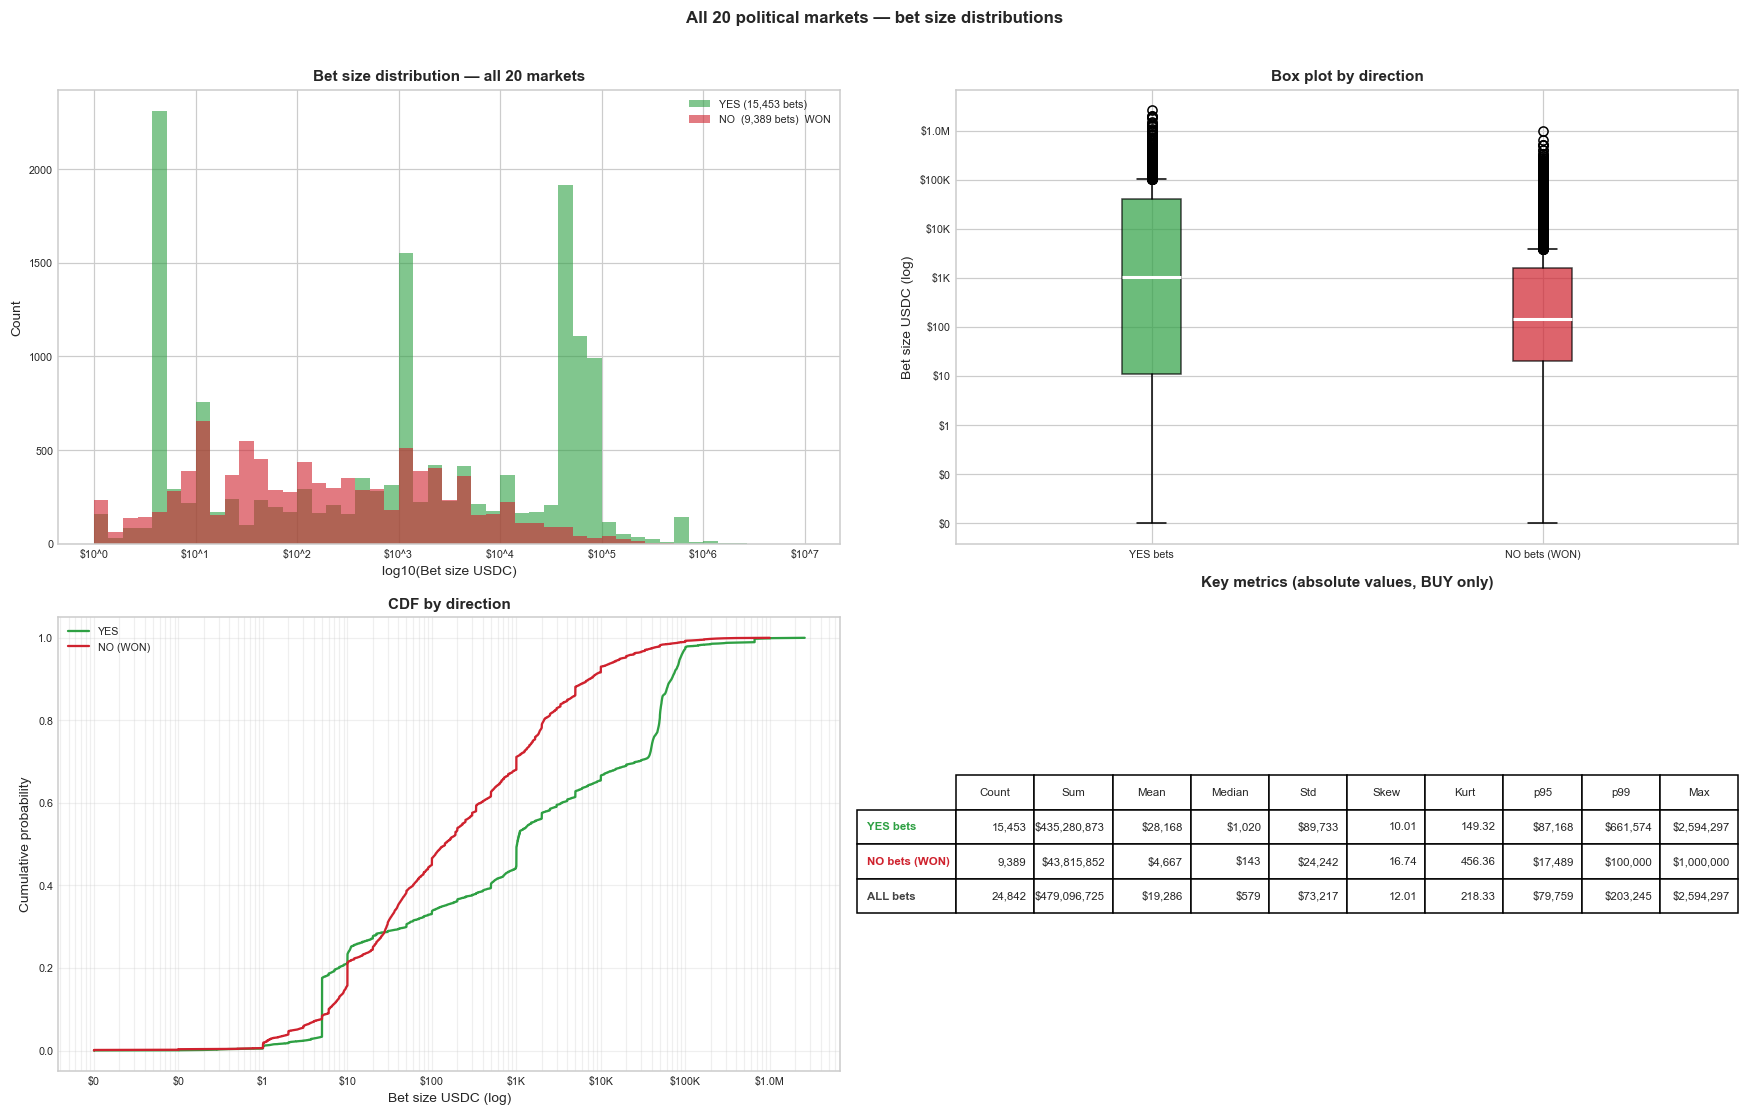

In [5]:
fig,axes = plt.subplots(2,2,figsize=(16,10))
bins = np.linspace(0,7,50)

ax = axes[0,0]
ax.hist(np.log10(yes_sizes[yes_sizes>0]),bins=bins,color=C_YES,alpha=0.6,
        label=f'YES ({len(yes_sizes):,} bets)')
ax.hist(np.log10(no_sizes[no_sizes>0]),  bins=bins,color=C_NO, alpha=0.6,
        label=f'NO  ({len(no_sizes):,} bets)  WON')
ax.set_xlabel('log10(Bet size USDC)')
ax.set_ylabel('Count')
ax.set_title('Bet size distribution — all 20 markets', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'$10^{int(round(v))}'))
ax.legend()

ax = axes[0,1]
bp = ax.boxplot([yes_sizes,no_sizes],patch_artist=True,
                medianprops=dict(color='white',linewidth=2))
bp['boxes'][0].set_facecolor(C_YES); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(C_NO);  bp['boxes'][1].set_alpha(0.7)
ax.set_xticks([1,2])
ax.set_xticklabels(['YES bets','NO bets (WON)'])
ax.set_yscale('log')
ax.yaxis.set_major_formatter(fmt_usdc)
ax.set_title('Box plot by direction', fontweight='bold')
ax.set_ylabel('Bet size USDC (log)')

ax = axes[1,0]
for sizes,col,lbl in [(np.sort(yes_sizes),C_YES,'YES'),
                       (np.sort(no_sizes), C_NO, 'NO (WON)')]:
    if len(sizes):
        ax.plot(sizes,np.arange(1,len(sizes)+1)/len(sizes),color=col,linewidth=1.5,label=lbl)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(fmt_usdc)
ax.set_xlabel('Bet size USDC (log)')
ax.set_ylabel('Cumulative probability')
ax.set_title('CDF by direction', fontweight='bold')
ax.legend(); ax.grid(True,which='both',alpha=0.3)

ax = axes[1,1]
ax.axis('off')
tbl = ax.table(
    cellText=[[r[k] for k in keys] for r in rows_s],
    rowLabels=[r['Label'] for r in rows_s],
    colLabels=keys, loc='center', cellLoc='right')
tbl.auto_set_font_size(False); tbl.set_fontsize(7.5); tbl.scale(1,1.6)
for i,col in enumerate([C_YES,C_NO,'#444']):
    tbl[(i+1,-1)].set_text_props(color=col,fontweight='bold')
ax.set_title('Key metrics (absolute values, BUY only)', fontweight='bold', pad=20)

plt.suptitle('All 20 political markets — bet size distributions',
             fontsize=11,fontweight='bold',y=1.01)
plt.tight_layout()
plt.show()

## Per-market distribution panels

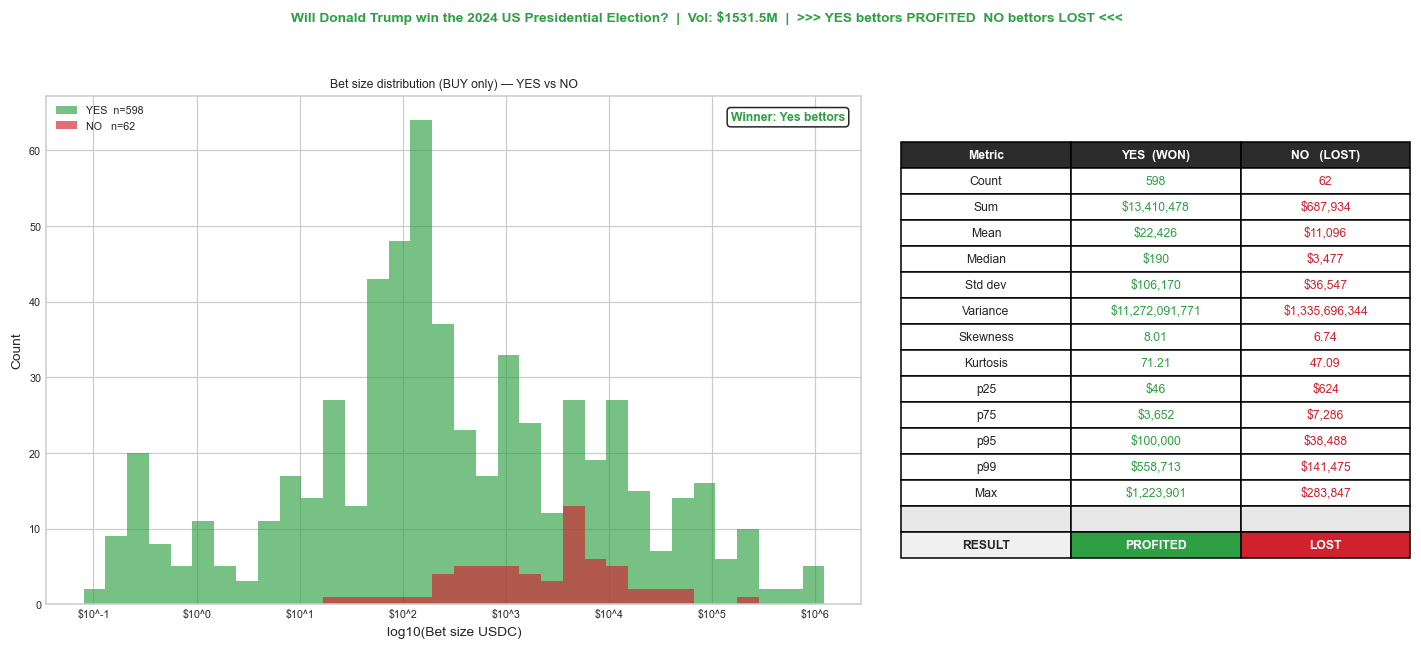

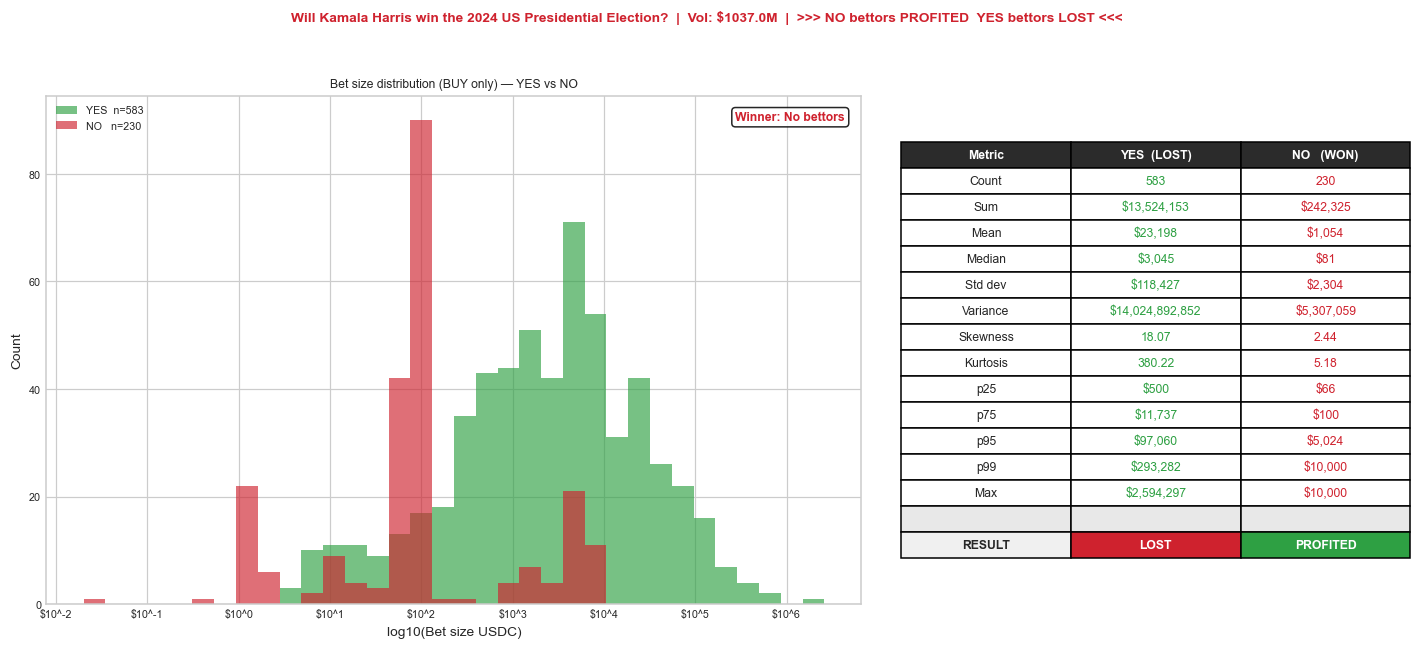

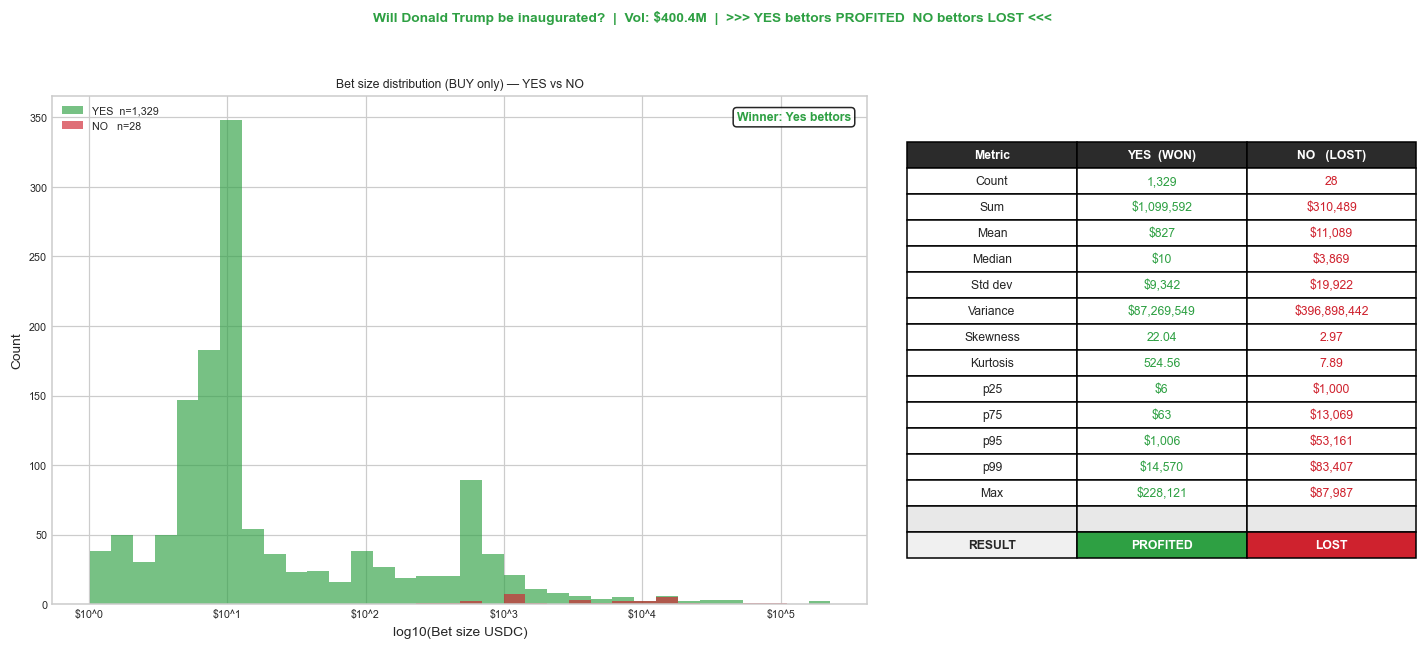

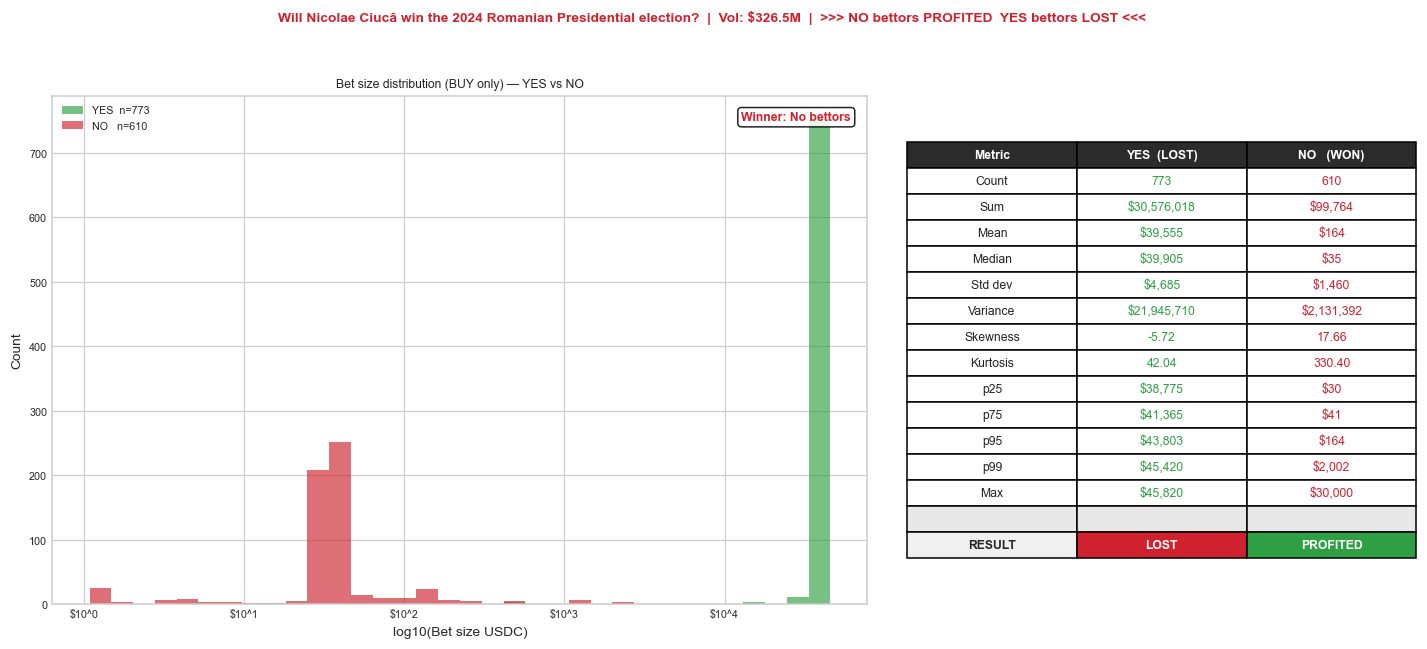

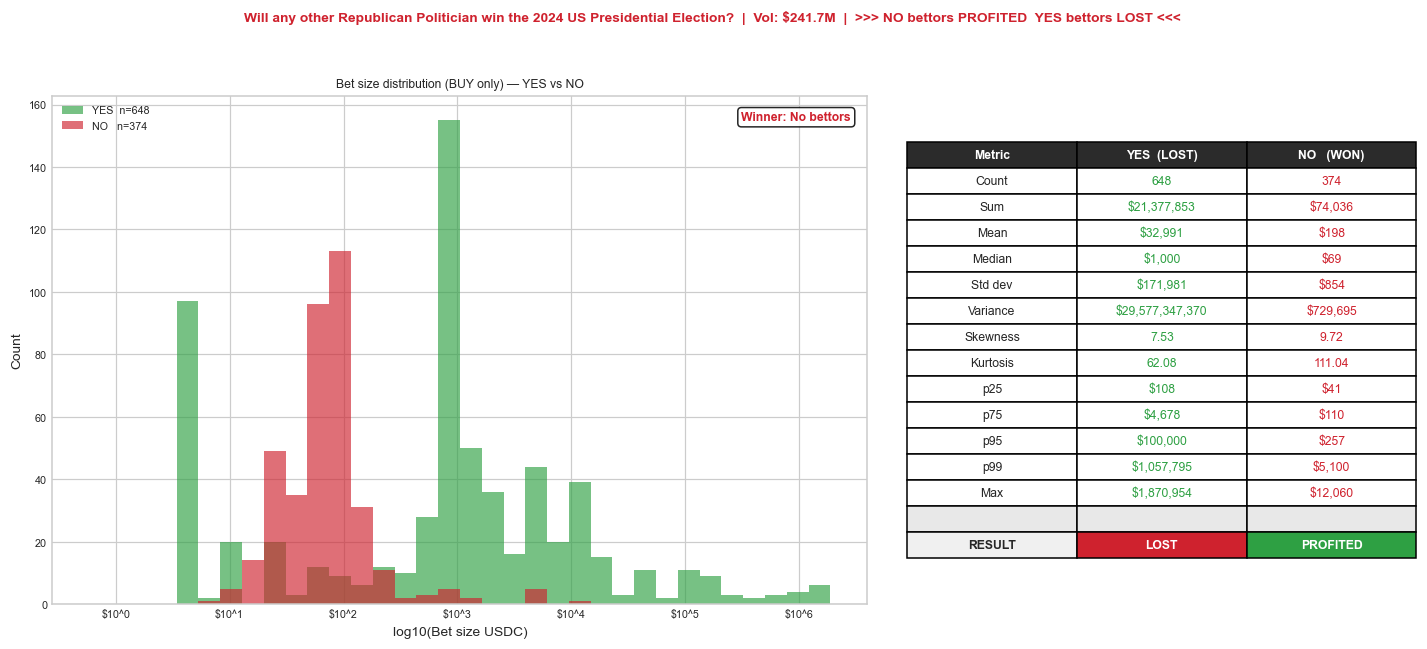

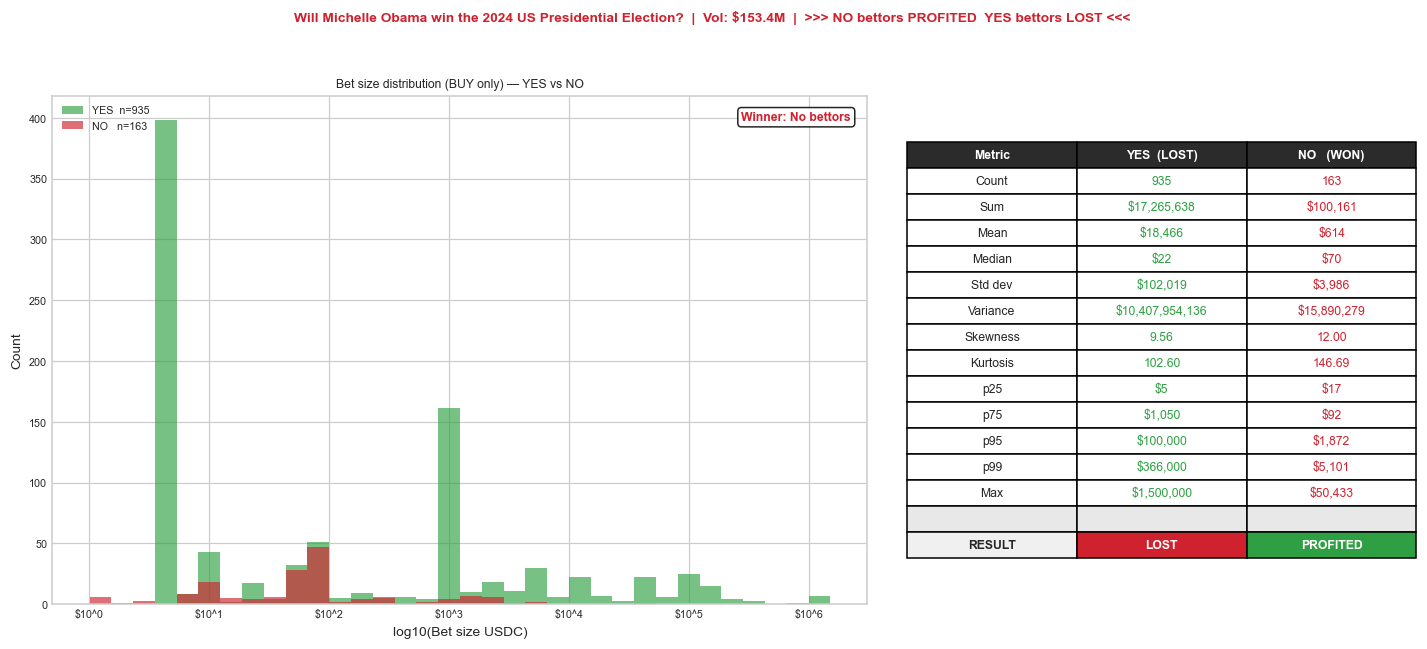

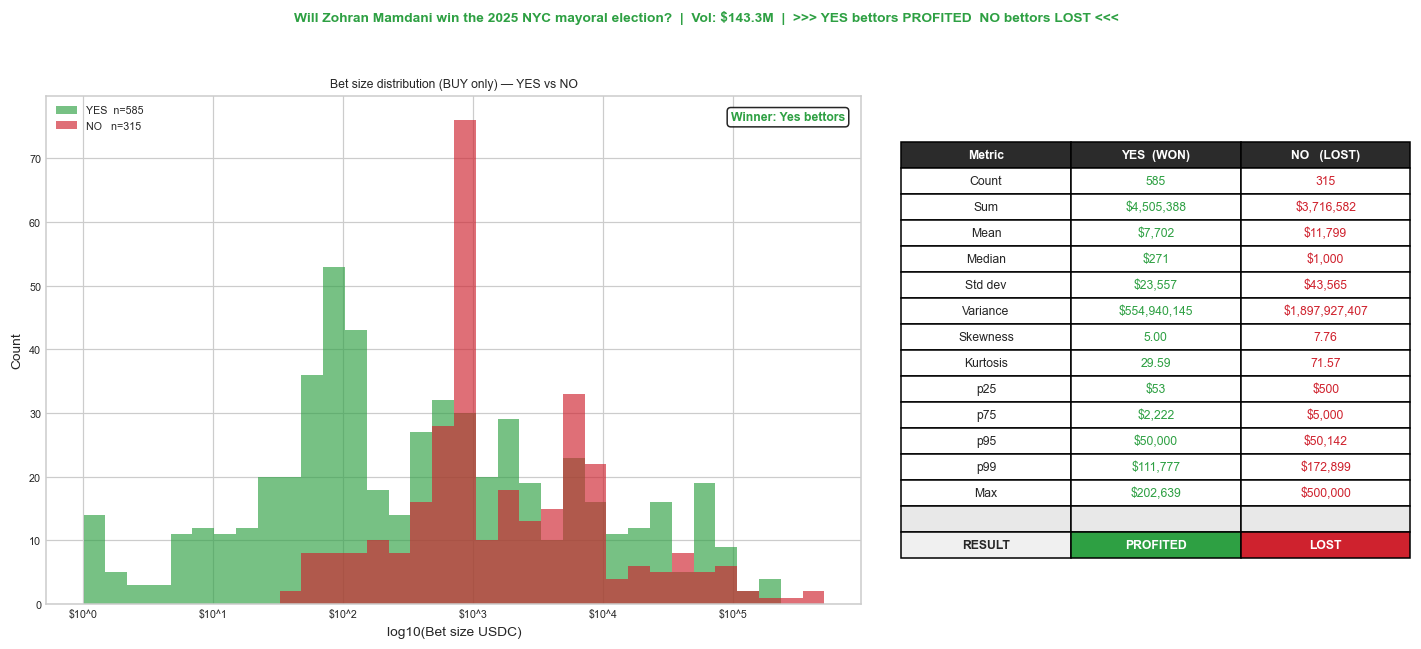

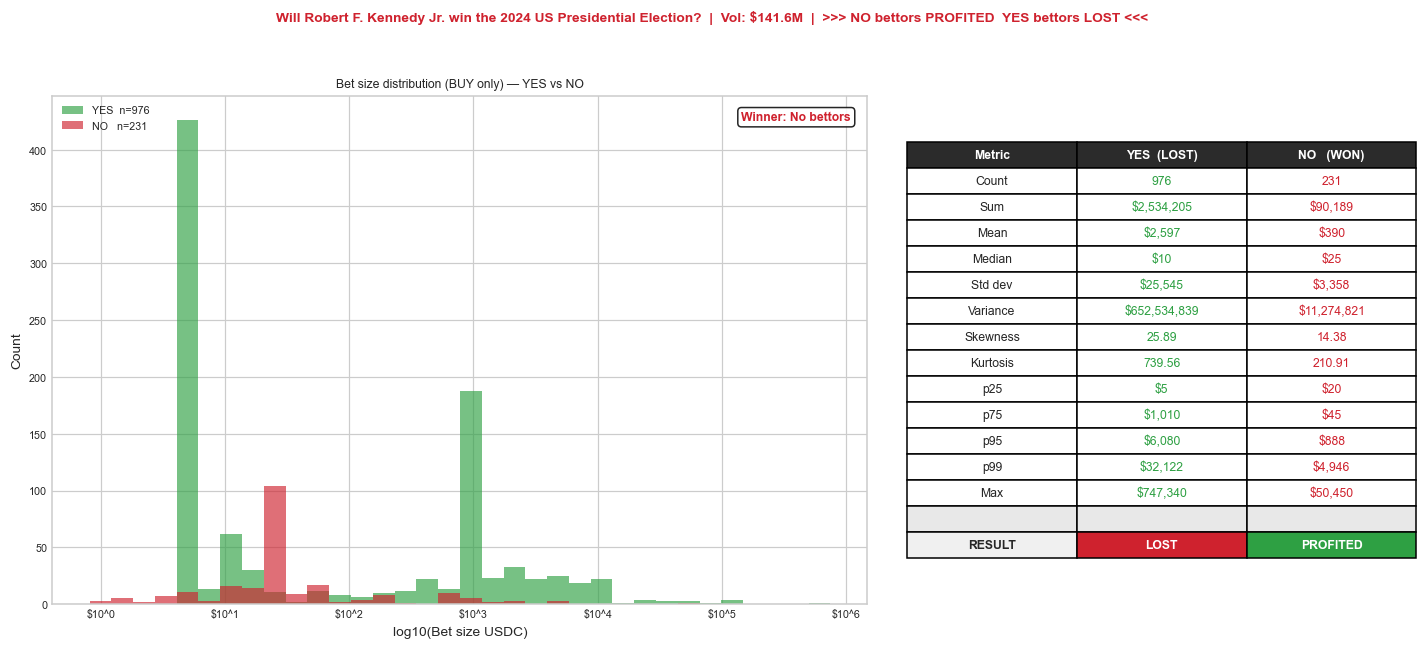

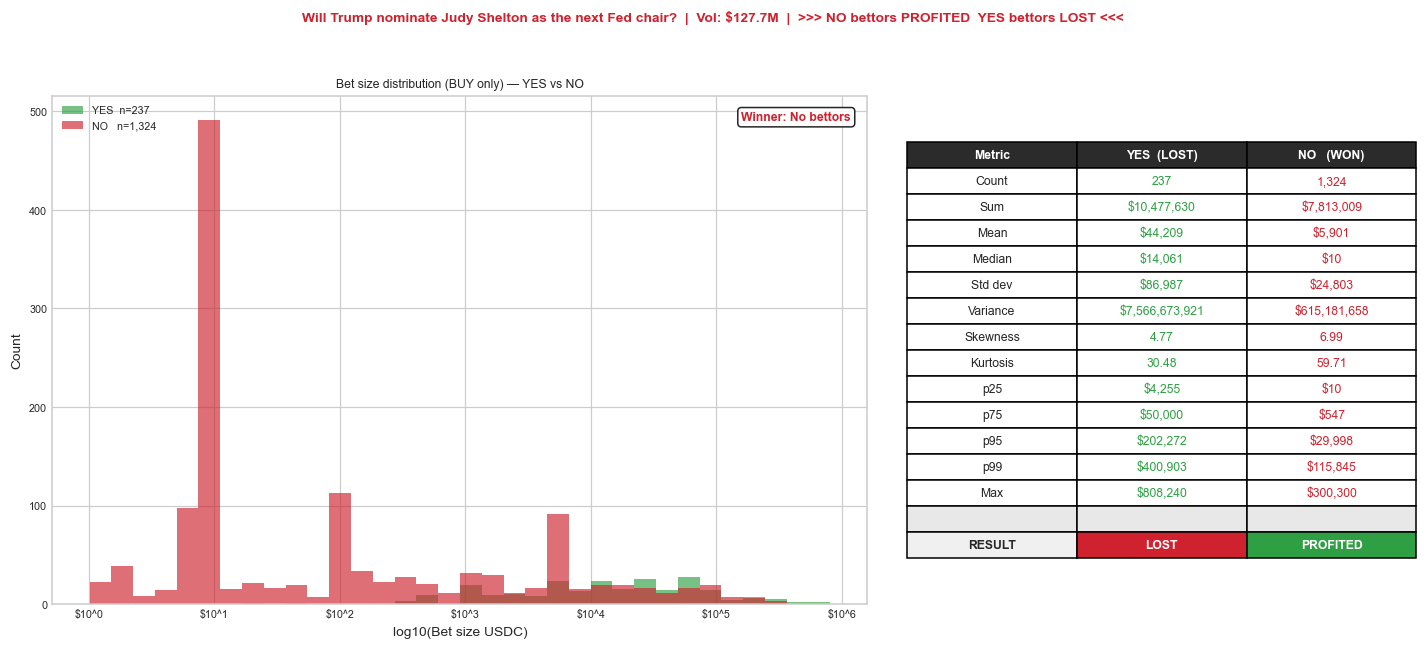

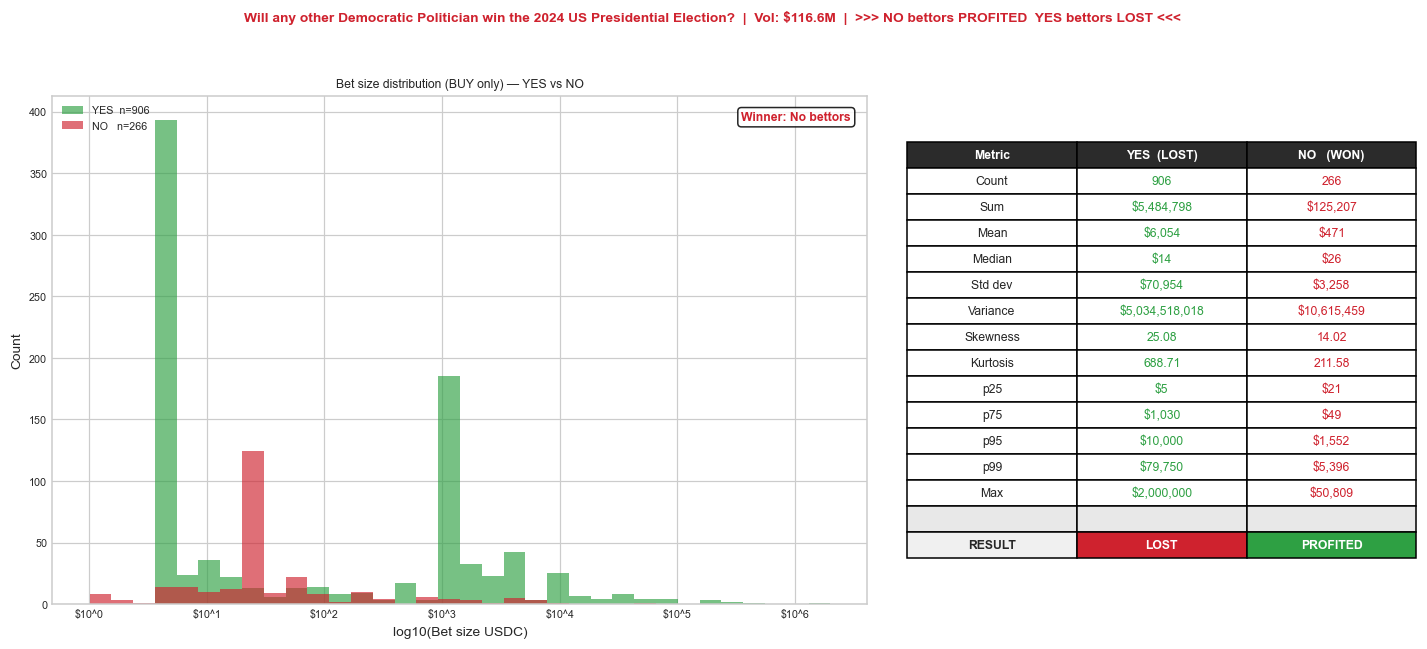

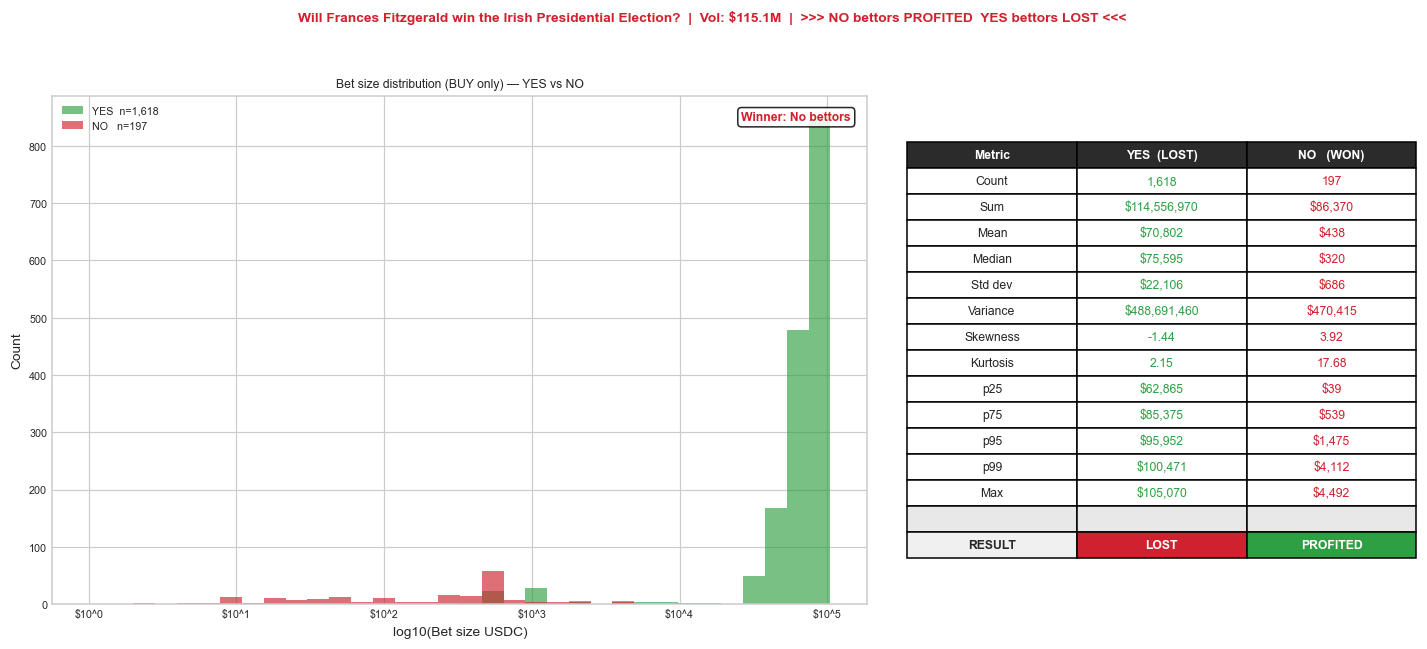

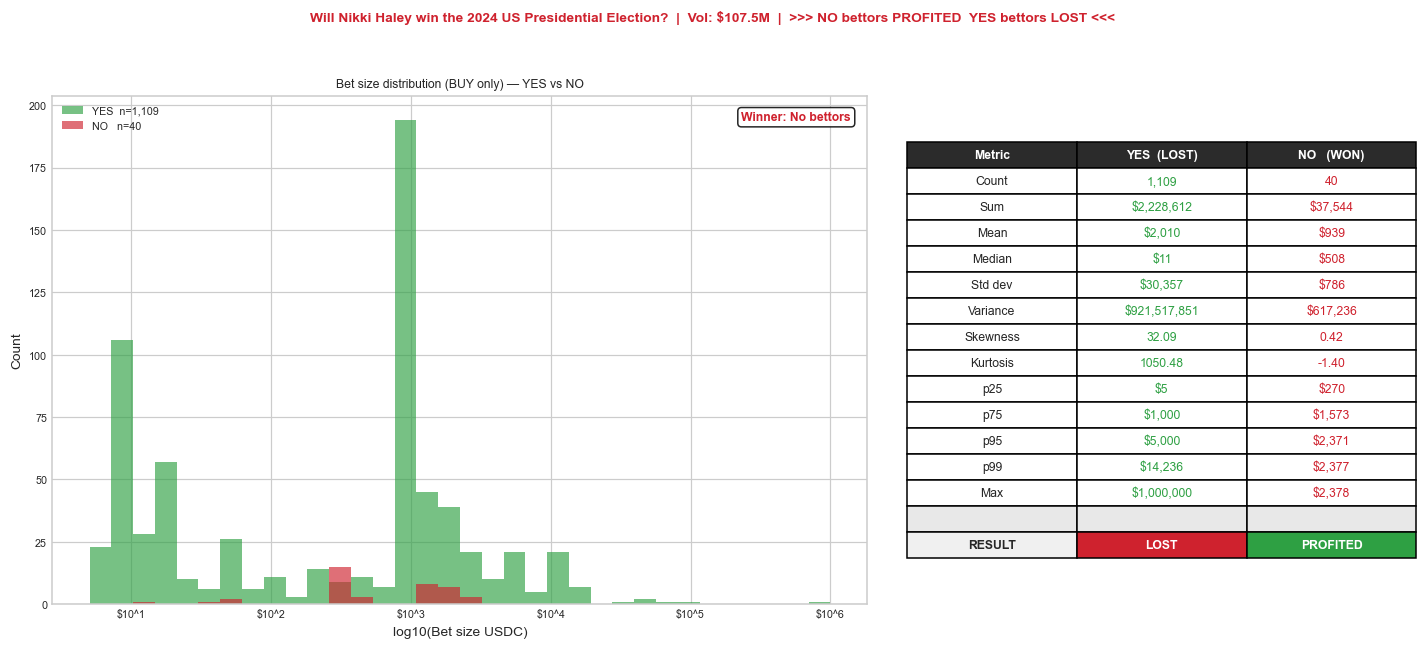

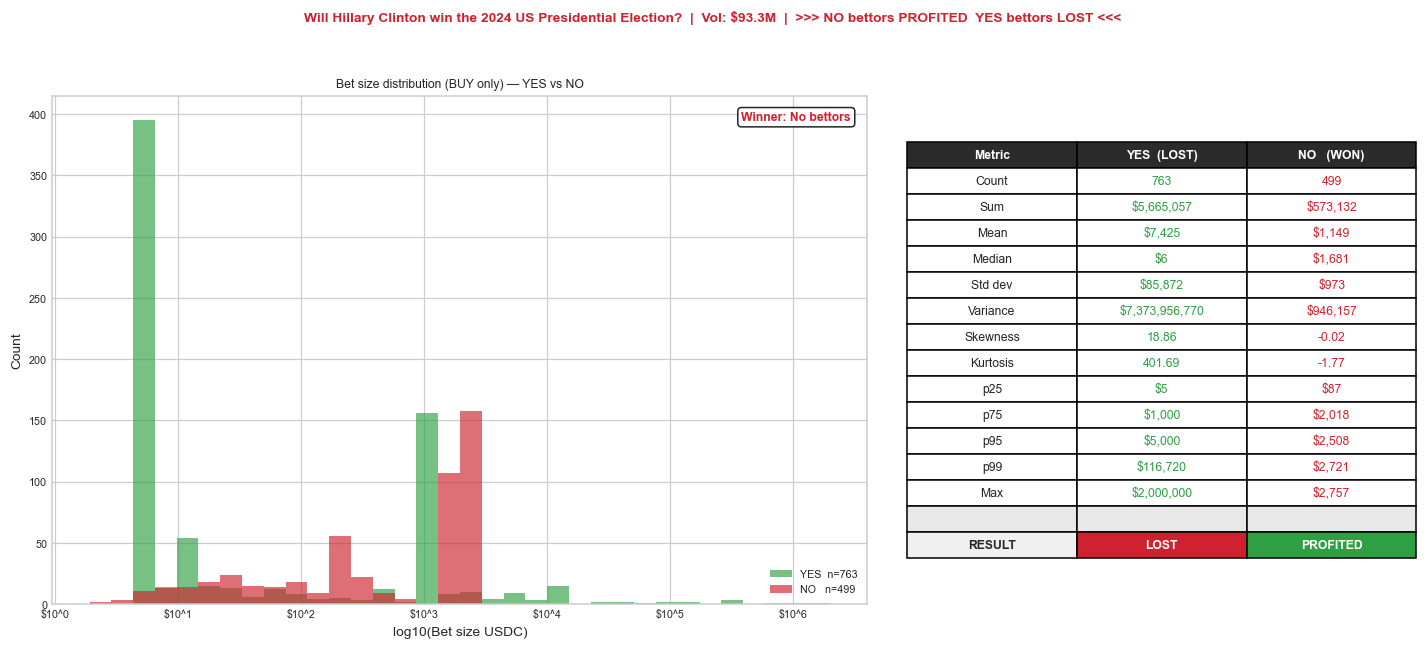

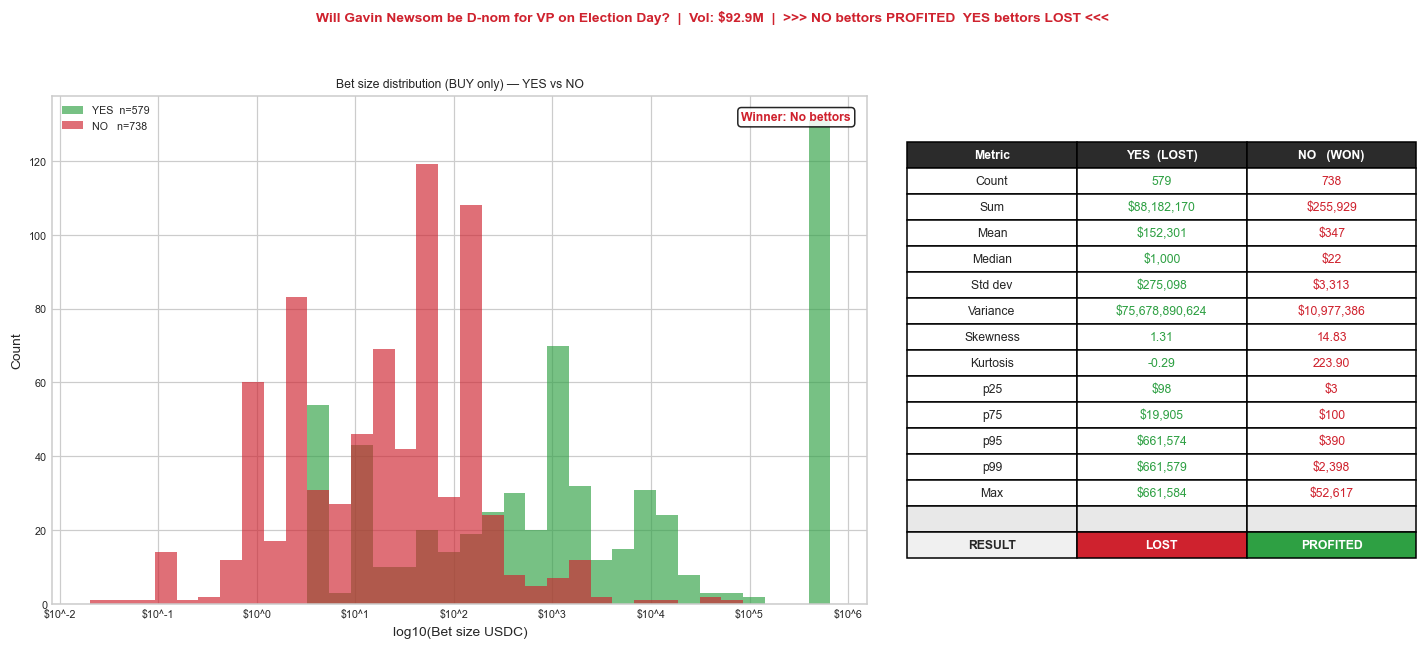

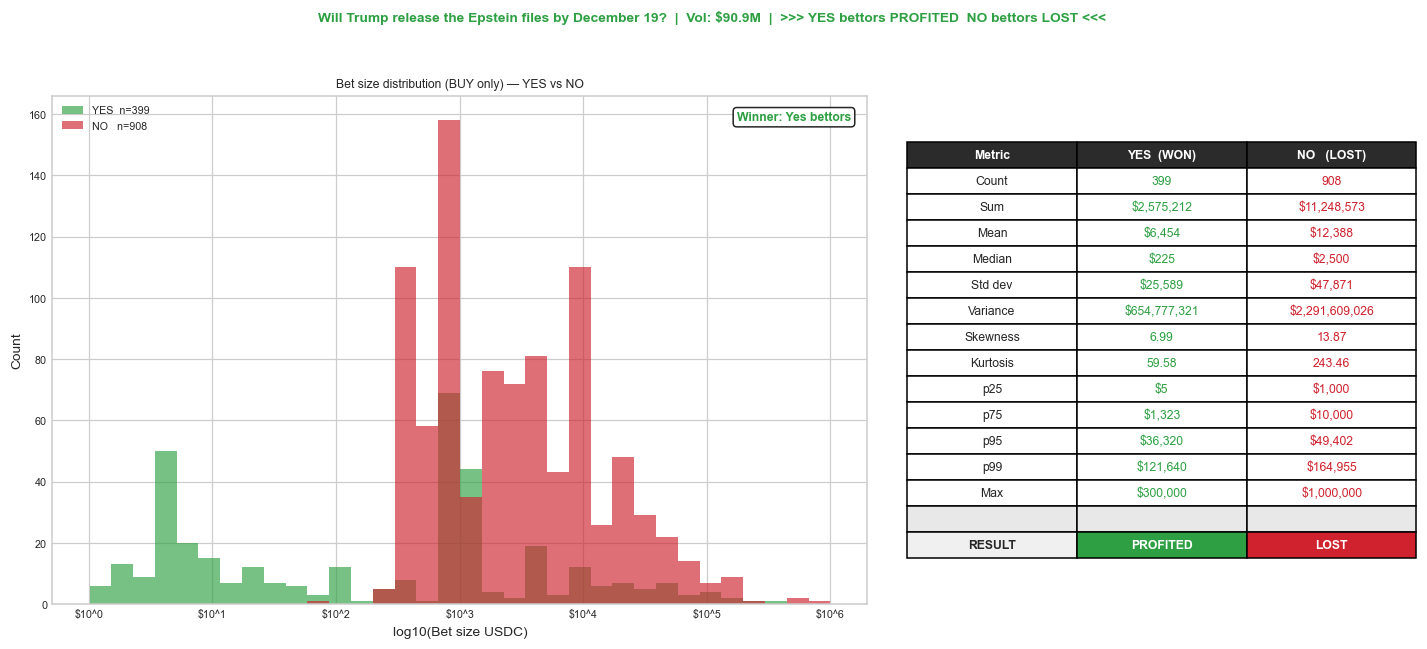

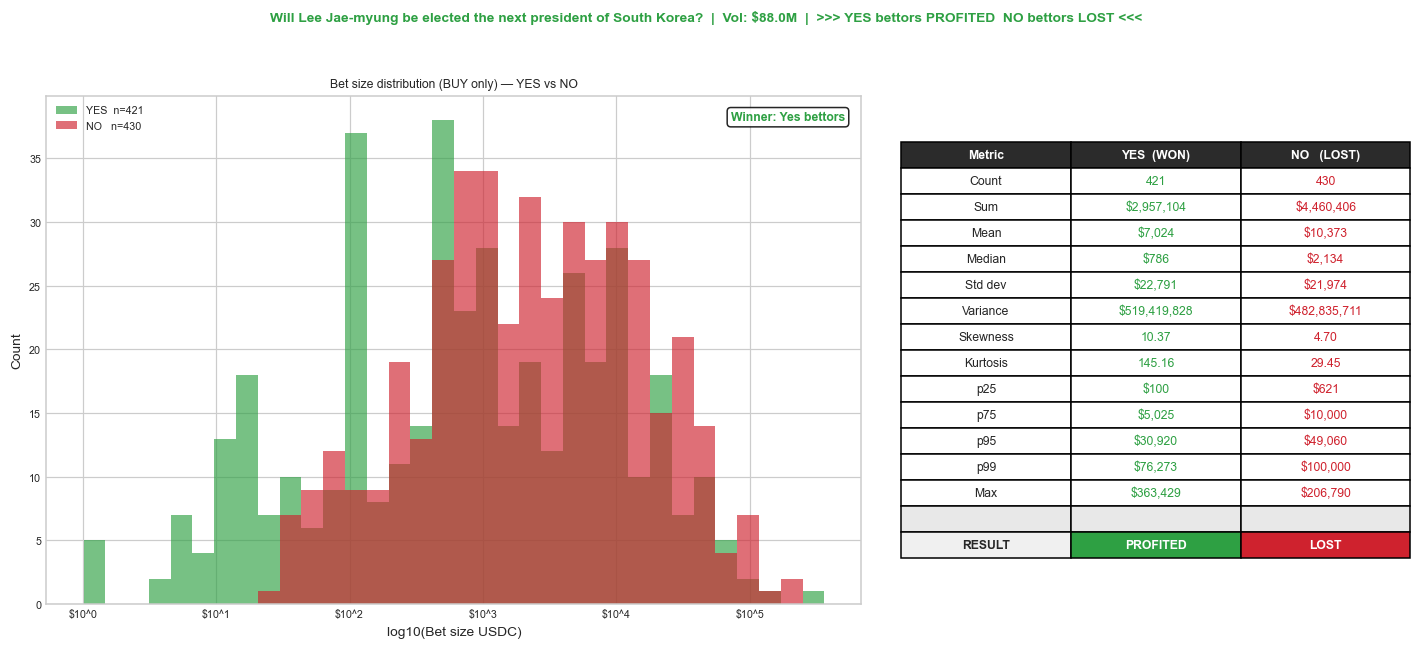

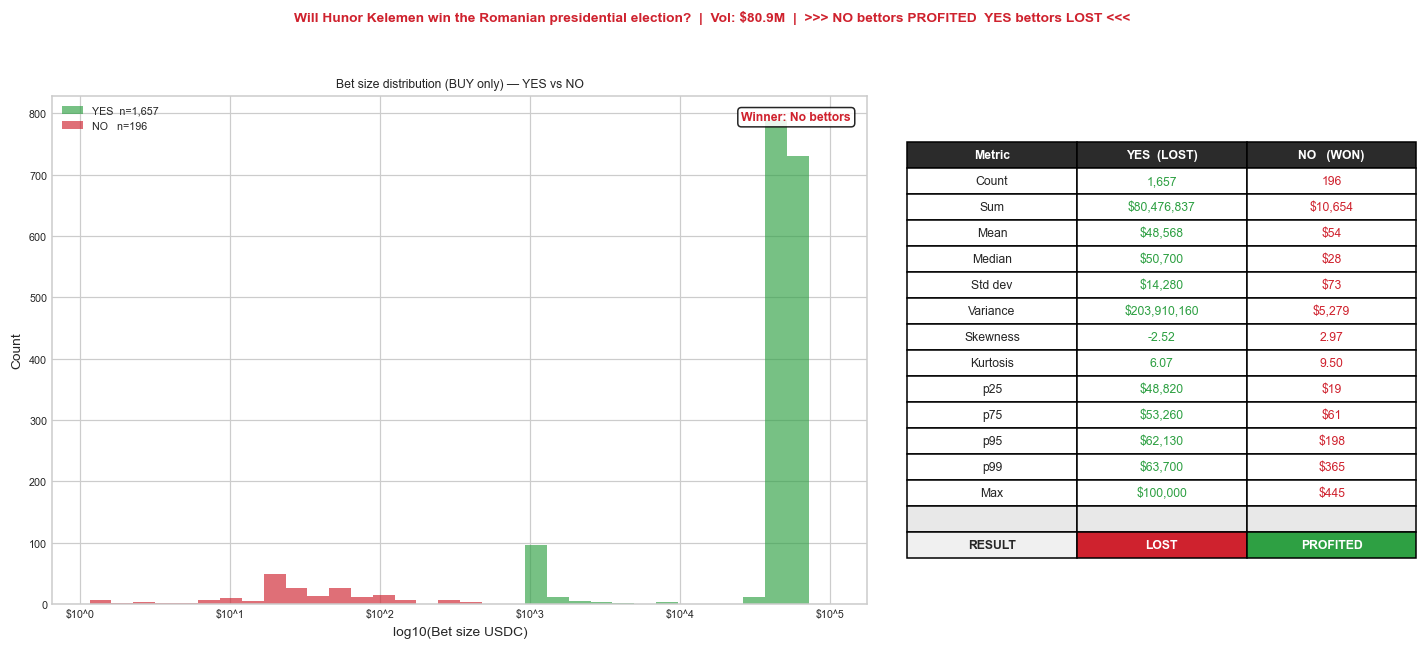

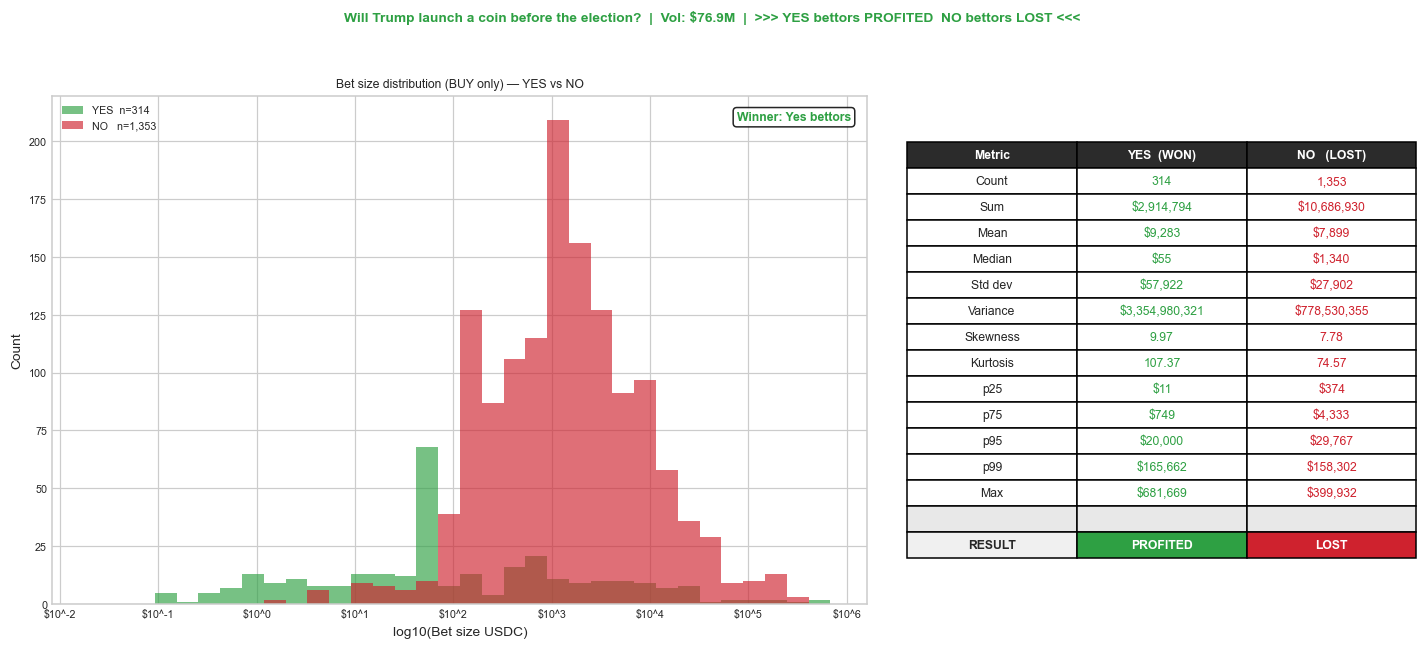

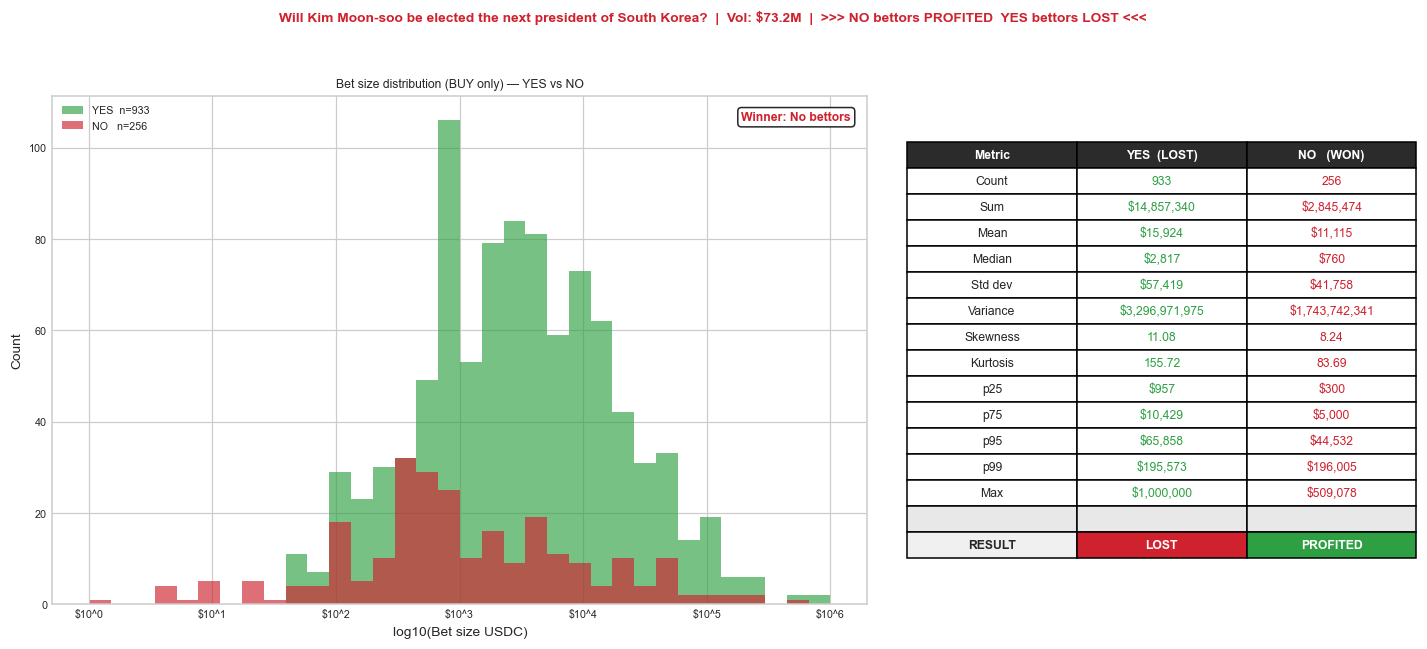

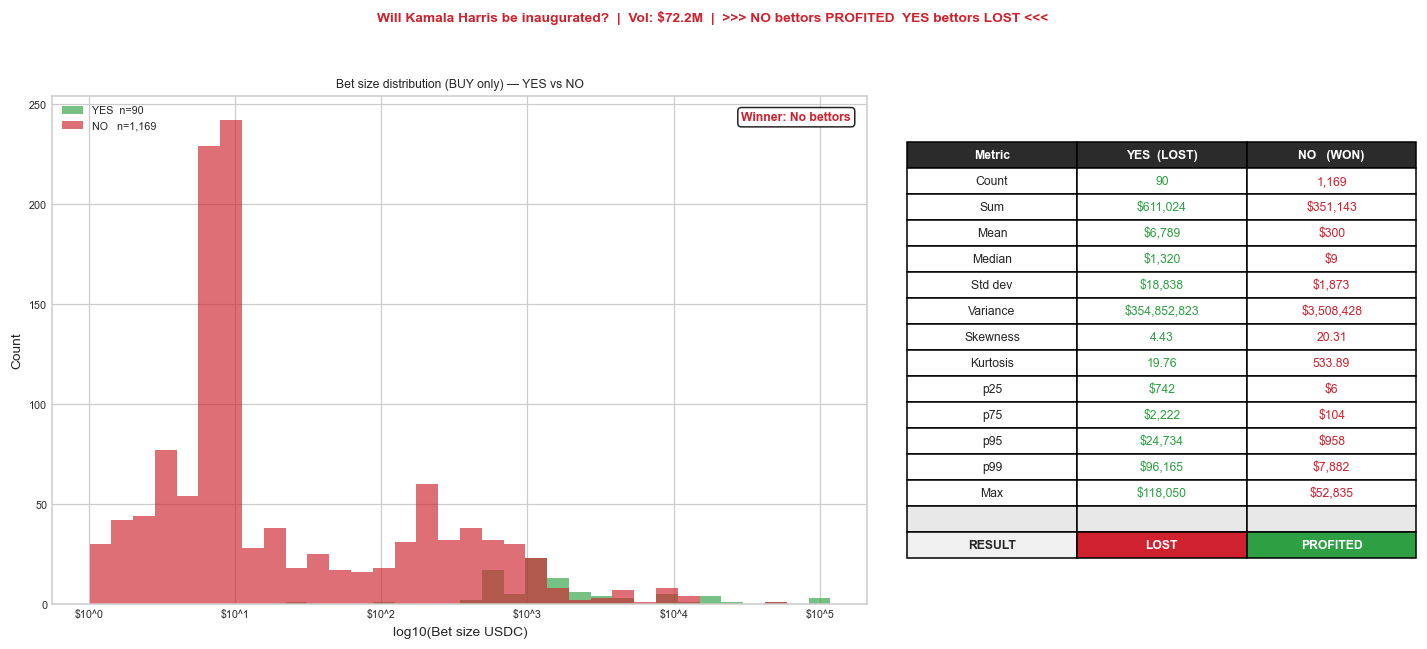

In [6]:
from scipy import stats as scipy_stats

mkt_list = list(markets.sort('volume_usdc', descending=True).iter_rows(named=True))

for row in mkt_list:
    mkt_b   = buys.filter(pl.col('slug') == row['slug'])
    ys = np.abs(mkt_b.filter(pl.col('outcome')=='Yes')['size'].to_numpy())
    ns = np.abs(mkt_b.filter(pl.col('outcome')=='No' )['size'].to_numpy())
    res     = row['resolution']
    yes_won = (res == 'Yes')
    c_w     = C_YES if yes_won else C_NO
    winner  = 'YES' if yes_won else 'NO'
    loser   = 'NO'  if yes_won else 'YES'
    vol     = float(row['volume_usdc'] or 0)

    def fmt(a):
        try:
            import math
            if math.isnan(float(a)): return 'n/a'
        except: pass
        return f'${a:,.0f}'

    fig = plt.figure(figsize=(16, 6))
    gs  = fig.add_gridspec(1, 2, width_ratios=[1.6, 1], wspace=0.06)
    ax_hist = fig.add_subplot(gs[0])
    ax_tbl  = fig.add_subplot(gs[1])

    fig.suptitle(
        row['question'] + f'  |  Vol: ${vol/1e6:.1f}M  |  >>> {winner} bettors PROFITED  {loser} bettors LOST <<<',
        fontsize=9, fontweight='bold', color=c_w, y=1.01
    )

    all_v = np.concatenate([ys[ys>0], ns[ns>0]])
    if len(all_v):
        bins = np.linspace(np.log10(all_v.min()+0.01), np.log10(all_v.max()+1), 35)
        if len(ys[ys>0]):
            ax_hist.hist(np.log10(ys[ys>0]), bins=bins, color=C_YES, alpha=0.65, label=f'YES  n={len(ys):,}')
        if len(ns[ns>0]):
            ax_hist.hist(np.log10(ns[ns>0]), bins=bins, color=C_NO,  alpha=0.65, label=f'NO   n={len(ns):,}')

    ax_hist.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: '$10^' + str(int(round(v)))))
    ax_hist.set_xlabel('log10(Bet size USDC)')
    ax_hist.set_ylabel('Count')
    ax_hist.set_title('Bet size distribution (BUY only) — YES vs NO', fontsize=8)
    ax_hist.legend(fontsize=7)
    ax_hist.text(0.98, 0.97, f'Winner: {res} bettors',
                 transform=ax_hist.transAxes, ha='right', va='top',
                 fontsize=8, fontweight='bold', color=c_w,
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

    ax_tbl.axis('off')
    yes_lbl = f'YES  ({"WON" if yes_won else "LOST"})'
    no_lbl  = f'NO   ({"WON" if not yes_won else "LOST"})'

    def st(a): return fmt(a.mean())           if len(a) else 'n/a'
    def md(a): return fmt(np.median(a))       if len(a) else 'n/a'
    def sd(a): return fmt(a.std())            if len(a) else 'n/a'
    def vr(a): return fmt(a.var())            if len(a) else 'n/a'
    def sk(a): return f'{scipy_stats.skew(a):.2f}'      if len(a)>2 else 'n/a'
    def ku(a): return f'{scipy_stats.kurtosis(a):.2f}'  if len(a)>2 else 'n/a'
    def pp(a,p): return fmt(np.percentile(a,p)) if len(a) else 'n/a'

    cell_data = [
        ['Count',    f'{len(ys):,}',                          f'{len(ns):,}'],
        ['Sum',      fmt(ys.sum()) if len(ys) else 'n/a',     fmt(ns.sum()) if len(ns) else 'n/a'],
        ['Mean',     st(ys),   st(ns)],
        ['Median',   md(ys),   md(ns)],
        ['Std dev',  sd(ys),   sd(ns)],
        ['Variance', vr(ys),   vr(ns)],
        ['Skewness', sk(ys),   sk(ns)],
        ['Kurtosis', ku(ys),   ku(ns)],
        ['p25',      pp(ys,25),pp(ns,25)],
        ['p75',      pp(ys,75),pp(ns,75)],
        ['p95',      pp(ys,95),pp(ns,95)],
        ['p99',      pp(ys,99),pp(ns,99)],
        ['Max',      fmt(ys.max()) if len(ys) else 'n/a',     fmt(ns.max()) if len(ns) else 'n/a'],
        ['', '', ''],
        ['RESULT',   'PROFITED' if yes_won else 'LOST',       'PROFITED' if not yes_won else 'LOST'],
    ]

    tbl = ax_tbl.table(
        cellText=cell_data,
        colLabels=['Metric', yes_lbl, no_lbl],
        loc='center', cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.42)

    for j in range(3):
        tbl[(0,j)].set_facecolor('#2b2b2b')
        tbl[(0,j)].set_text_props(color='white', fontweight='bold')

    for i, row_d in enumerate(cell_data, 1):
        tbl[(i,1)].set_text_props(color=C_YES)
        tbl[(i,2)].set_text_props(color=C_NO)
        if row_d[0] == '':
            for j in range(3):
                tbl[(i,j)].set_facecolor('#e8e8e8')
                tbl[(i,j)].set_text_props(color='#e8e8e8')
        if row_d[0] == 'RESULT':
            win_j = 1 if yes_won else 2
            los_j = 2 if yes_won else 1
            tbl[(i, win_j)].set_facecolor(C_YES)
            tbl[(i, win_j)].set_text_props(color='white', fontweight='bold')
            tbl[(i, los_j)].set_facecolor(C_NO)
            tbl[(i, los_j)].set_text_props(color='white', fontweight='bold')
            tbl[(i, 0)].set_facecolor('#f0f0f0')
            tbl[(i, 0)].set_text_props(fontweight='bold')

    plt.tight_layout()
    plt.show()
    plt.close(fig)


## Top 20 largest bets across all markets

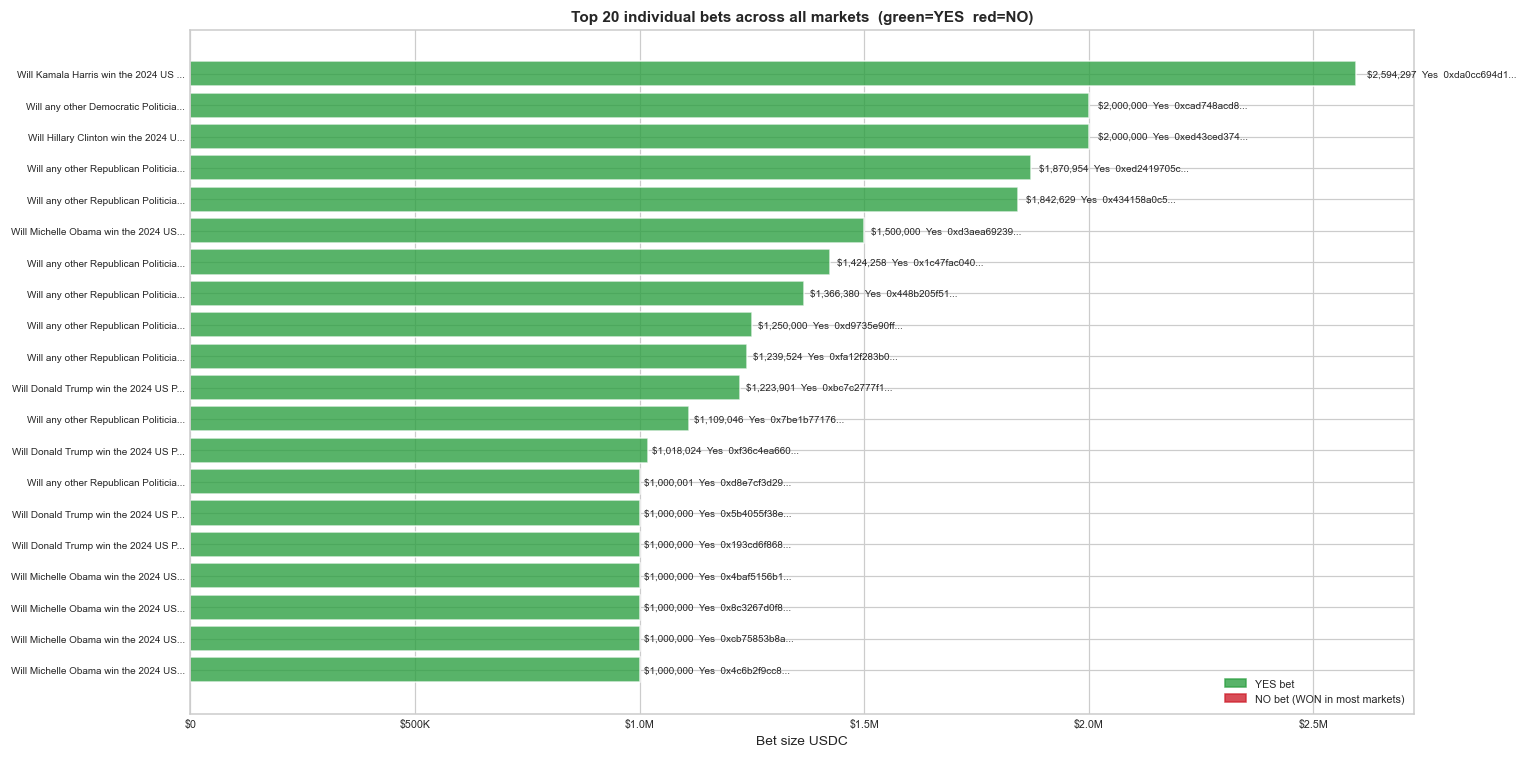


CSV files saved to EDA/csv/
  market_bets.csv : 40,000 rows
  maduro_bets.csv : already saved


In [7]:
from datetime import datetime
top20=buys.sort('size',descending=True).head(20)
fig,ax=plt.subplots(figsize=(14,7))
for i,r in enumerate(top20.iter_rows(named=True)):
    col=C_YES if r['outcome']=='Yes' else C_NO
    ax.barh(i,r['size'],color=col,alpha=0.8,edgecolor='white')
    lbl=f'\${r["size"]:,.0f}  {r["outcome"]}  {r.get("tx_hash","")[:12]}...'
    ax.text(r['size']*1.01,i,lbl,va='center',fontsize=6.5)
labels=[r['market'][:35]+'...' if len(r['market'])>35 else r['market']
        for r in top20.iter_rows(named=True)]
ax.set_yticks(range(20)); ax.set_yticklabels(labels,fontsize=6.5)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(fmt_usdc)
ax.set_xlabel('Bet size USDC')
ax.set_title('Top 20 individual bets across all markets  (green=YES  red=NO)',fontweight='bold')
yes_p=mpatches.Patch(color=C_YES,label='YES bet',alpha=0.8)
no_p =mpatches.Patch(color=C_NO, label='NO bet (WON in most markets)',alpha=0.8)
ax.legend(handles=[yes_p,no_p])
plt.tight_layout(); plt.show()

print(f'\nCSV files saved to EDA/csv/')
print(f'  market_bets.csv : {len(df):,} rows')
print(f'  maduro_bets.csv : already saved')